# LSTM Model


Upload your 3 CSV files:
1. preprocessed_augmented_dataset_scaled.csv
2. validation_set_scaled.csv
3. test_set_scaled.csv


Saving test_set_scaled.csv to test_set_scaled (1).csv
Saving validation_set_scaled.csv to validation_set_scaled (1).csv
Saving preprocessed_augmented_dataset_scaled.csv to preprocessed_augmented_dataset_scaled (1).csv
Train file: preprocessed_augmented_dataset_scaled.csv
Val file:   validation_set_scaled (1).csv
Test file:  test_set_scaled.csv
Training samples:   100000
Validation samples: 320
Test samples:       330
Number of features: 19
Number of classes:  10
Input shape: (100000, 1, 19)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 64)          │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,506 (572.29 KB)

 Trainable params: 146,122 (570.79 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9009 - loss: 0.2801 - val_accuracy: 0.9375 - val_loss: 0.2164 - learning_rate: 0.0010
Epoch 2/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9574 - loss: 0.1274 - val_accuracy: 0.9406 - val_loss: 0.1918 - learning_rate: 0.0010
Epoch 3/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9655 - loss: 0.1032 - val_accuracy: 0.9312 - val_loss: 0.2205 - learning_rate: 0.0010
Epoch 4/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9711 - loss: 0.0856 - val_accuracy: 0.9500 - val_loss: 0.1866 - learning_rate: 0.0010
Epoch 5/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9743 - loss: 0.0752 - val_accuracy: 0.9469 - val_loss: 0.1952 - learning_rate: 0.0010
Epoch 6/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9778 - loss: 0.0640 - val_accuracy: 0.9438 - val_loss: 0.2950 - learning_rate: 0.0010
Epoch 7/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9801 - loss: 0

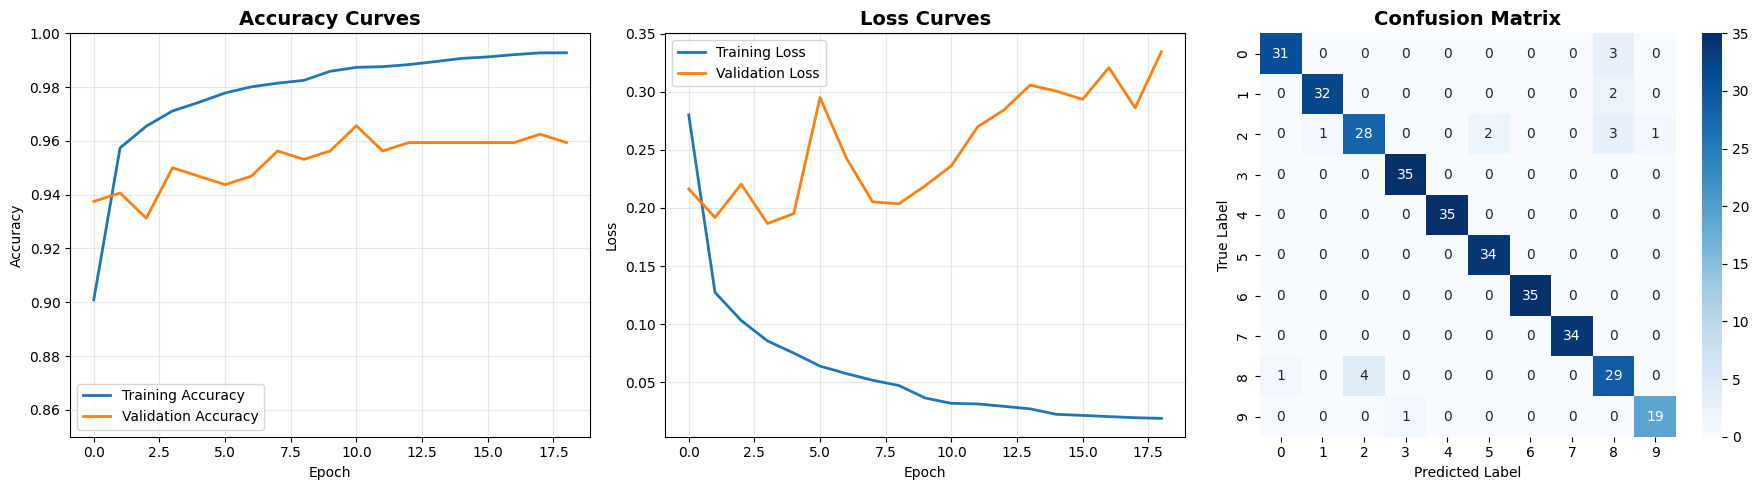


Model saved as: lstm_model_final.keras
Evaluation plot saved as: final_lstm_evaluation.png


In [ ]:
# ============================================================
# FINAL LSTM MODEL - BEARING FAULT DETECTION
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)

# ============================================================
# 1. UPLOAD DATASET FILES
# ============================================================

print("\nUpload your 3 CSV files:")
print("1. preprocessed_augmented_dataset_scaled.csv")
print("2. validation_set_scaled.csv")
print("3. test_set_scaled.csv")

from google.colab import files
uploaded = files.upload()

def find_file(keyword):
    for f in os.listdir():
        if keyword in f.lower():
            return f
    return None

train_file = find_file("augmented")
val_file = find_file("validation")
test_file = find_file("test")

missing = []
if train_file is None:
    missing.append("training set (file containing 'augmented')")
if val_file is None:
    missing.append("validation set (file containing 'validation')")
if test_file is None:
    missing.append("test set (file containing 'test')")

if missing:
    raise FileNotFoundError(
        "Missing required files: " + ", ".join(missing) +
        "\nCurrent directory contents: " + ", ".join(os.listdir())
    )

print(f"Train file: {train_file}")
print(f"Val file:   {val_file}")
print(f"Test file:  {test_file}")

# ============================================================
# 2. LOAD AND PREPARE DATA
# ============================================================

train_df = pd.read_csv(train_file)
val_df = pd.read_csv(val_file)
test_df = pd.read_csv(test_file)

X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_val = val_df.iloc[:, :-1].values
y_val = val_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

print(f"Training samples:   {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples:       {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of classes:  {len(np.unique(y_train))}")

y_train_cat = to_categorical(y_train)
y_val_cat = to_categorical(y_val)
y_test_cat = to_categorical(y_test)

X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

print(f"Input shape: {X_train.shape}")

# ============================================================
# 3. BUILD FINAL OPTIMIZED MODEL
# Ablation findings integrated below:
#   - L2 regularization removed (no improvement, 95.15% vs 94.24%)
#   - Class weights removed (hurt performance by 0.3%)
#   - Dropout and BatchNorm kept (each adds ~0.6% accuracy)
#   - Two LSTM layers kept (single layer loses 1.2% accuracy)
#   - Dense(64) kept (loses 1.2% accuracy if removed)
#   - Bidirectional rejected (overfits with 1-timestep input)
# ============================================================

model = Sequential([
    Input(shape=(1, X_train.shape[2])),

    # LSTM(64) returning sequences for stacking (kept; single LSTM costs -1.2%)
    LSTM(64, return_sequences=True, activation='tanh'),
    BatchNormalization(),  # Kept; removing costs -0.6% accuracy
    Dropout(0.3),          # Kept; removing costs -0.6% accuracy

    # Second LSTM layer (kept for hierarchical feature extraction)
    LSTM(128, return_sequences=False, activation='tanh'),
    BatchNormalization(),
    Dropout(0.3),

    # Dense layers (Dense64 kept; removing costs -1.2% accuracy)
    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    # Output layer (10 bearing fault classes)
    Dense(y_train_cat.shape[1], activation='softmax')
])

# L2 regularization omitted per ablation findings (no benefit)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================================
# 4. TRAIN MODEL
# ============================================================

early_stop = EarlyStopping(patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(
    X_train, y_train_cat,
    epochs=80,
    batch_size=128,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stop, reduce_lr],
    # Class weights removed per ablation (tied best at 95.15% without them)
    verbose=1
)

actual_epochs = len(history.history['accuracy'])
print(f"\nTrained for {actual_epochs} epochs")

# ============================================================
# 5. EVALUATE ON TEST SET
# ============================================================

y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted')
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

print("\n" + "=" * 80)
print("FINAL MODEL PERFORMANCE")
print("=" * 80)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("=" * 80)

print("\nAblation benchmark comparison:")
print(f"  Baseline (with L2 + class weights) : 94.24%")
print(f"  Optimized (without L2 + class weights): {accuracy*100:.2f}%")
print(f"  Improvement: +{(accuracy - 0.9424)*100:.2f}%")

# ============================================================
# 6. VISUALIZATION
# ============================================================

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Accuracy Curves', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([0.85, 1.0])

plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Loss Curves', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
cm = confusion_matrix(y_test, y_pred_classes)
class_names = [str(i) for i in range(len(np.unique(y_test)))]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.savefig("final_lstm_evaluation.png", dpi=150)
plt.show()

# ============================================================
# 7. SAVE MODEL
# ============================================================

model.save("lstm_model_final.keras")
print("\nModel saved as: lstm_model_final.keras")
print("Evaluation plot saved as: final_lstm_evaluation.png")